In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import functions
import glob as glob
import cartopy.crs as ccrs
import matplotlib as mpl

In [2]:
fbkdir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedbacks/'
tempdir = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedback_input/'

In [3]:
cldtype = 'ALL'
experiments = ['abrupt-0_5xCO2', 'abrupt-2xCO2', 'abrupt-4xCO2']
ds_list = []
dT_list = []
dT_annavg_list = []

interval=30
if interval == 30:
    tslicelist = [slice('1920-01-01', '1949-12-31'), slice('1950-01-01', '1979-12-31'),
                slice('1980-01-01', '2009-12-31'), slice('2010-01-01', '2039-12-31'),
                slice('2040-01-01', '2069-12-31')]
elif interval == 15:
    tslicelist = [slice('1920-01-01', '1934-12-31'), slice('1935-01-01', '1949-12-31'),
                slice('1950-01-01', '1964-12-31'), slice('1965-01-01', '1979-12-31'),
                slice('1980-01-01', '1994-12-31'), slice('1995-01-01', '2009-12-31'),
                slice('2010-01-01', '2024-12-31'), slice('2025-01-01', '2039-12-31'),
                slice('2040-01-01', '2054-12-31'), slice('2055-01-01', '2069-12-31')]
elif interval == 10:
    tslicelist = [slice('1920-01', '1929-12'), slice('1930-01-01', '1939-12-31'),
                slice('1940-01-01', '1949-12-31'), slice('1950-01-01', '1959-12-31'),
                slice('1960-01-01', '1969-12-31'), slice('1970-01-01', '1979-12-31'),
                slice('1980-01-01', '1989-12-31'), slice('1990-01-01', '1999-12-31'),
                slice('2000-01-01', '2009-12-31'), slice('2010-01-01', '2019-12-31'),
                slice('2020-01-01', '2029-12-31'), slice('2030-01-01', '2039-12-31'),
                slice('2040-01-01', '2049-12-31'), slice('2050-01-01', '2059-12-31'),
                slice('2060-01-01', '2069-12-31')]
N = int(150/interval)

pi_temp = xr.open_dataset(tempdir+'tas_piClim_final30years.nc')
pi_temp = pi_temp.groupby('time.month').mean('time')
pi_temp = pi_temp.rename({'month':'time'})
pi_temp_annavg = pi_temp.mean('time')

for exp in experiments:

    fbk_files = glob.glob(fbkdir+'interval'+str(interval)+'/'+cldtype+'_'+exp+'_*')
    fbk_files.sort()
    fbk_ds = xr.open_mfdataset(fbk_files, combine='nested', concat_dim='period')
    ds_list.append(fbk_ds)

    temp_ds = xr.open_dataset(tempdir+'tas_'+exp+'_1920-01-01_2069-12-31.nc')

    temp_annavg = temp_ds.groupby('time.year').mean('time')
    temp_annavg['tas'] = temp_annavg['tas'] - pi_temp_annavg['tas']
    dT_annavg_list.append(temp_annavg)
    
    dT = []
    for tslice in tslicelist:
        temp_slice = temp_ds.sel(time=tslice)
        temp_slice = temp_slice.groupby('time.month').mean('time')
        temp_slice = temp_slice.rename({'month':'time'})
        temp_slice['tas'] = temp_slice['tas'] - pi_temp['tas']
        dT.append(temp_slice)

    dT = xr.concat(dT, dim='period')
    dT_list.append(dT)


ds = xr.concat(ds_list, dim='co2_conc')
ds = ds.assign_coords({'period':np.arange(N)*interval})
ds = ds.assign_coords({'co2_conc':['0.5xCO2', '2xCO2', '4xCO2']})

ds_dT = xr.concat(dT_list, dim='co2_conc')
ds_dT = ds_dT.assign_coords({'period':np.arange(N)*interval})
ds_dT = ds_dT.assign_coords({'co2_conc':['0.5xCO2', '2xCO2', '4xCO2']})

ds_dT_annavg = xr.concat(dT_annavg_list, dim='co2_conc')

<>:10: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:11: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:10: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:11: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_709225/2163438706.py:10: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.title('60$^{\circ}$N-90$^{\circ}$N', fontweight='bold', fontsize=15)
/tmp/ipykernel_709225/2163438706.py:11: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in

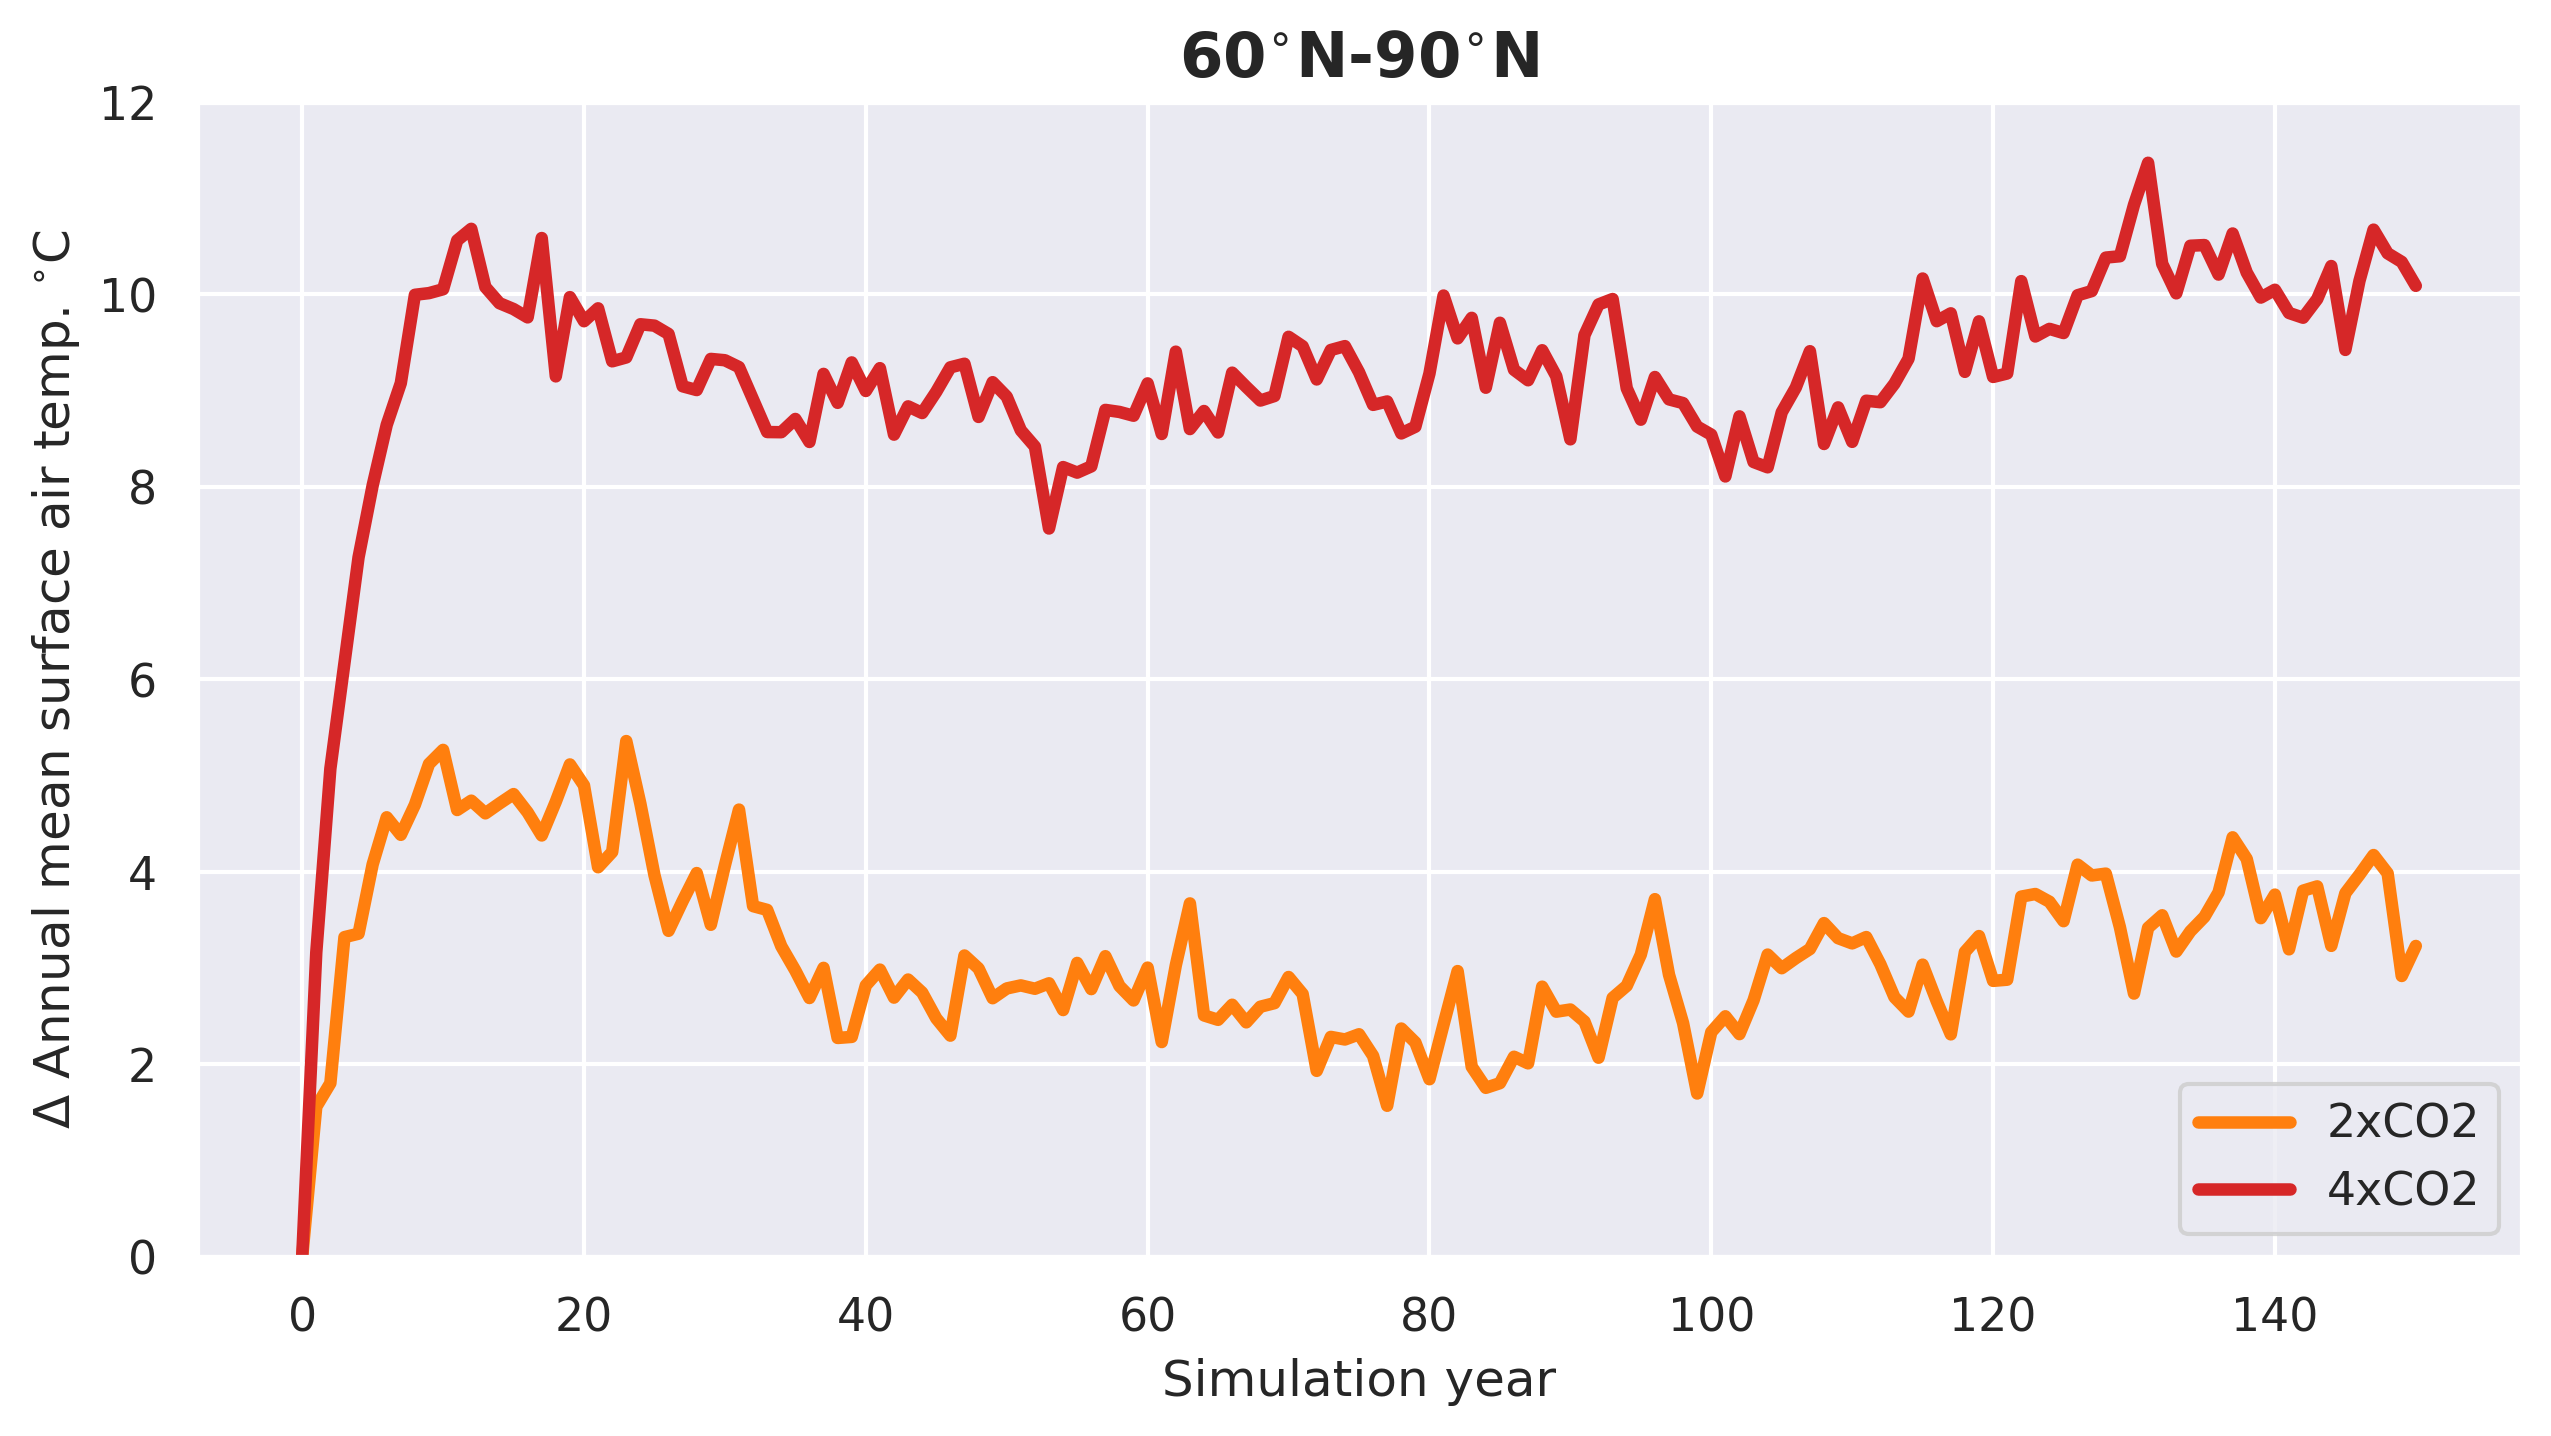

In [ ]:
import seaborn as sns
sns.set_theme()

ds_temp_annavg = functions.computeWeightedMean(ds_dT_annavg.sel(lat=slice(60,90)))

plt.figure(dpi=300, figsize=(10,5))
#plt.plot(np.arange(150), ds_temp_annavg['tas'].isel(co2_conc=0), lw=3, label='0.5xCO2', color='tab:blue')
plt.plot(np.arange(151), [0]+list(ds_temp_annavg['tas'].isel(co2_conc=1)), lw=3, label='2xCO2', color='tab:orange')
plt.plot(np.arange(151), [0]+list(ds_temp_annavg['tas'].isel(co2_conc=2)), lw=3, label='4xCO2', color='tab:red')
plt.xlabel('Simulation year')
plt.legend(loc='best')
plt.title('60$^{\circ}$N-90$^{\circ}$N', fontweight='bold', fontsize=15)
plt.ylabel('$\Delta$ Annual mean surface air temp. $^{\circ}$C')
plt.ylim([0, 12])
#plt.grid()
#box = plt.gca().get_position()
#plt.gca().set_position([box.x0, box.y0 + box.height * 0.1,
#                box.width, box.height * 0.9])
#plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)
plt.legend(loc='best')

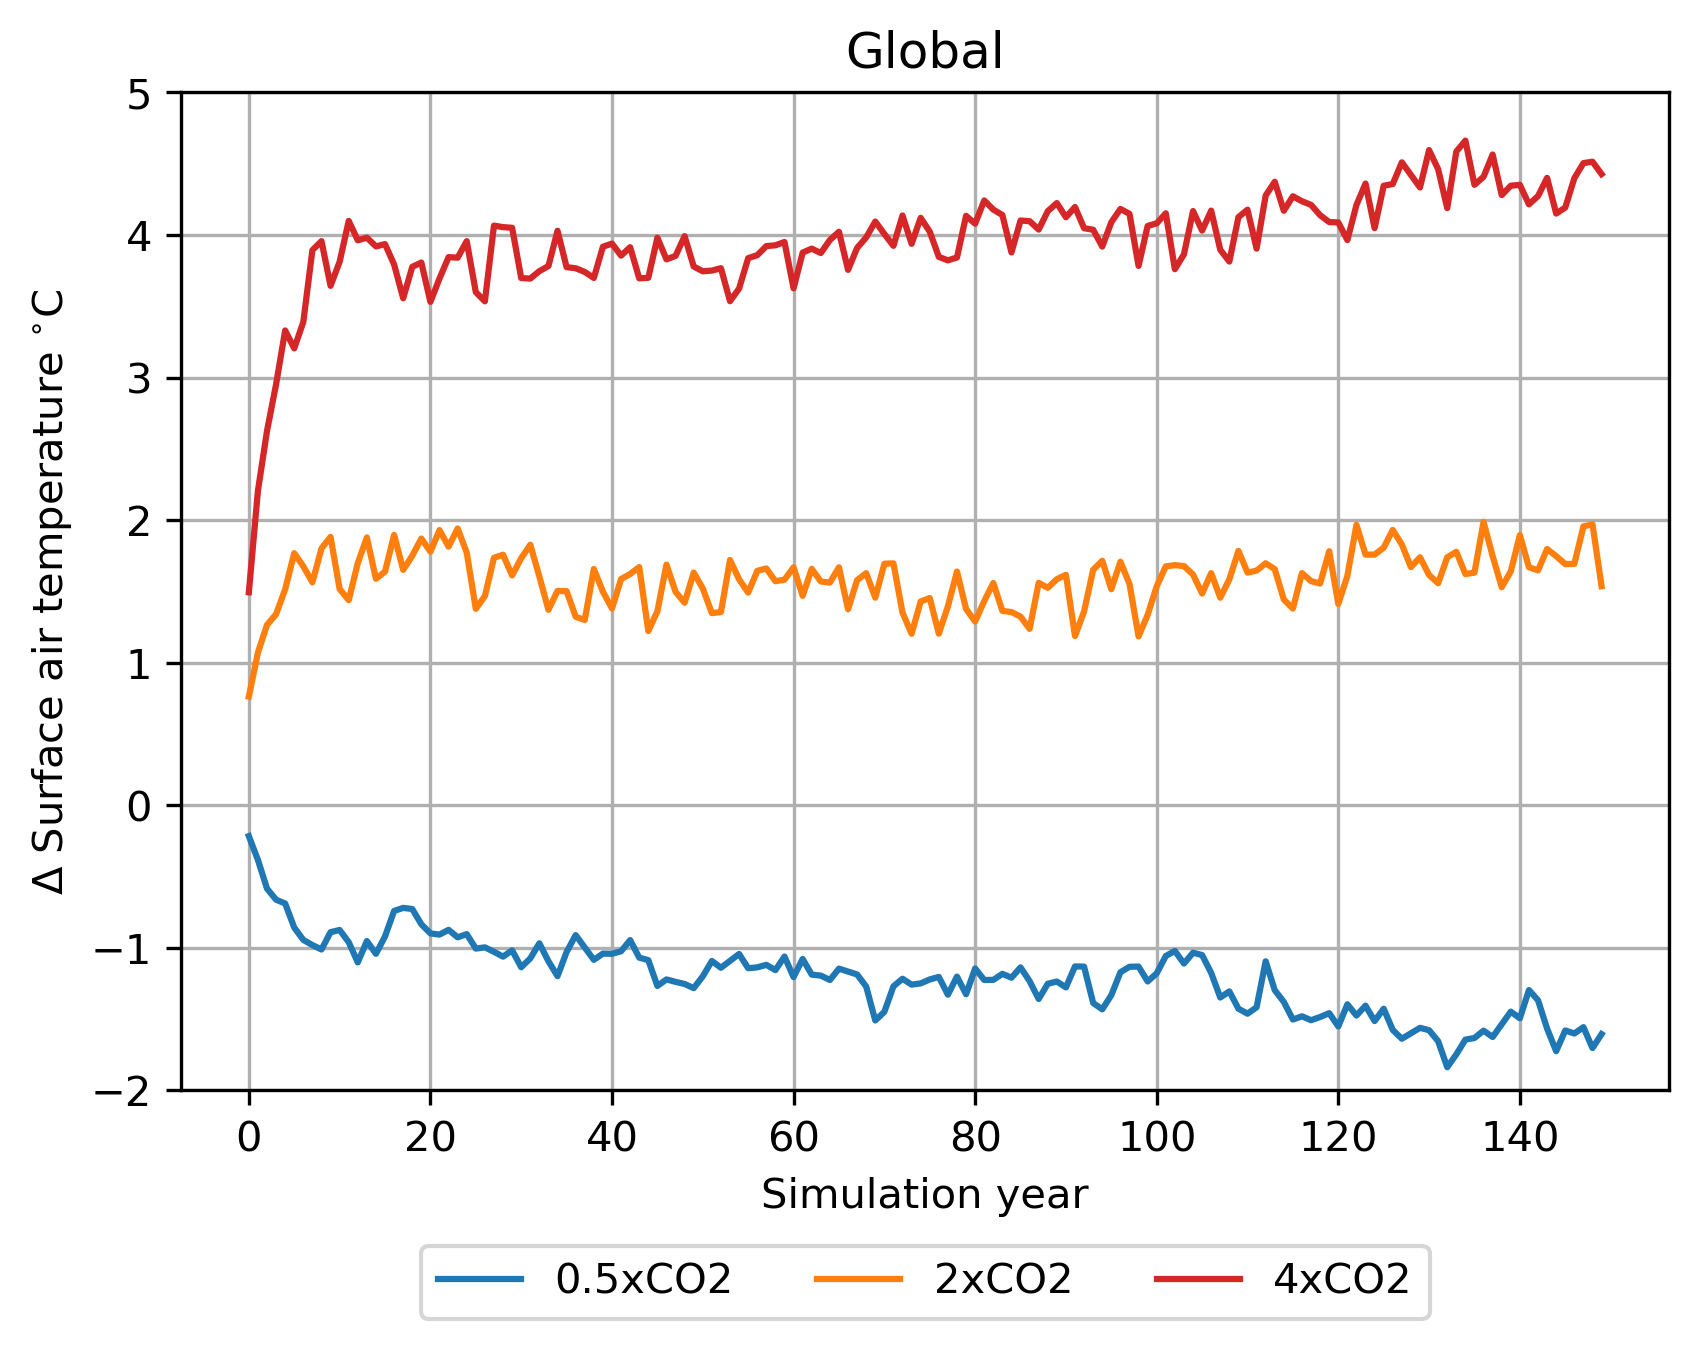

In [5]:
ds_temp_annavg = functions.computeWeightedMean(ds_dT_annavg.sel(lat=slice(-90,90)))

plt.figure(dpi=300)
plt.plot(np.arange(150), ds_temp_annavg['tas'].isel(co2_conc=0), label='0.5xCO2', color='tab:blue')
plt.plot(np.arange(150), ds_temp_annavg['tas'].isel(co2_conc=1), label='2xCO2', color='tab:orange')
plt.plot(np.arange(150), ds_temp_annavg['tas'].isel(co2_conc=2), label='4xCO2', color='tab:red')
plt.xlabel('Simulation year')
plt.legend(loc='best')
plt.title('Global')
plt.ylabel('$\Delta$ Surface air temperature $^{\circ}$C')
plt.ylim([-2, 5])
plt.grid()
box = plt.gca().get_position()
plt.gca().set_position([box.x0, box.y0 + box.height * 0.1,
                box.width, box.height * 0.9])
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)